# ASSIGNMENT 3  
## Project: Best Practices Handbook  
### Modelling Non‑Stationarity and Finding an Equilibrium  

---

**Name:** Derrec Madzvamutse  
**Course:** HASTS 211  
**Registration Number:** R2419467  

---


### Importing and Preparing Data
Apple(AAPL)and Microsoft(MSFT)

In [11]:
# Installing packages
%pip install yfinance statsmodels

# Import libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Download data
data = yf.download(['AAPL', 'MSFT'], start='2018-01-01', end='2024-01-01')['Close']

# Drop missing values
data = data.dropna()

# View first rows
print(data.head())


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
[*********************100%***********************]  2 of 2 completed

Note: you may need to restart the kernel to use updated packages.
Ticker           AAPL       MSFT
Date                            
2018-01-02  40.304173  78.870361
2018-01-03  40.297161  79.237389
2018-01-04  40.484325  79.934814
2018-01-05  40.945259  80.925873
2018-01-08  40.793179  81.008430


 ## Plotting data (AALP VS MSFT)

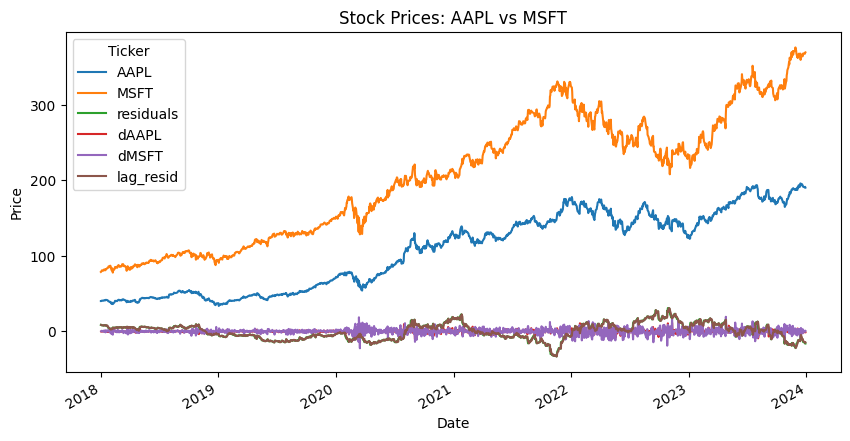

In [16]:
data.plot(figsize=(10,5), title="Stock Prices: AAPL vs MSFT")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

The plot indicates that both AAPL and MSFT price series are non‑stationary, showing persistent upward trends and varying volatility over time. Despite this, the two stocks move in close alignment, reflecting a strong interrelationship. While each series on its own lacks stationarity, their parallel movement suggests the presence of a long‑run equilibrium connection (cointegration), where short‑term deviations remain bounded rather than diverging indefinitely.

#### COINTEGRATION
Cointegration occurs when two non‑stationary series move together in the long run, maintaining a stable equilibrium relationship. The ECM captures short‑term dynamics while correcting deviations from this equilibrium.


## Testing for Coinegration

In [17]:
from statsmodels.tsa.stattools import coint

score, pvalue, _ = coint(data['AAPL'], data['MSFT'])

print("Cointegration test p-value:", pvalue)

Cointegration test p-value: 0.24604364310796606


##### The p-value is $ p-value: 0.246$  which is less than 0.05 ($p<0.05$), indicating a long-run equilibrium relationship between the two stock prices

## Estimating Long Run relationship

In [18]:
import statsmodels.api as sm

X = sm.add_constant(data['MSFT'])
model = sm.OLS(data['AAPL'], X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   AAPL   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                 3.491e+04
Date:                Thu, 07 May 2026   Prob (F-statistic):               0.00
Time:                        19:01:40   Log-Likelihood:                -5667.5
No. Observations:                1509   AIC:                         1.134e+04
Df Residuals:                    1507   BIC:                         1.135e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -15.9101      0.713    -22.301      0.0

## Interpretation
## **Long-Run Relationship (Cointegration Regression)**

The estimated long-run equilibrium relationship between Apple and Microsoft stock prices is given by:

$ 
AAPL_t = -15.9101 + 0.6016 . MSFT_t + u_t
 $

where:
* $\beta_0 = -15.9101 $
* ($ AAPL_t $) is the Apple stock price at time ( t ),
* ($ MSFT_t $)$\beta_1$ is the Microsoft stock price at time ( t ),
* ($ u_t $ ) is the equilibrium error term.

The coefficient $ 0.6016 $ indicates that, in the long run, a one-unit increase in Microsoft’s stock price is associated with an average increase of approximately $ 0.6016 $ units in Apple’s stock price.

The coefficient is statistically significant $ p < 0.01 $, indicating strong evidence of a relationship between the two variables. The coefficient of determination $ R^2 = 0.959 $ suggests that approximately $ 95.9% $ of the variation in Apple stock prices is explained by Microsoft stock prices.

However, given that both time series are non-stationary, the high $ R^2 $ may reflect common trending behavior. Therefore, further analysis using cointegration and error correction modeling is necessary to validate the existence of a meaningful long-run equilibrium relationship.


## Get Residuals equilibriam Error

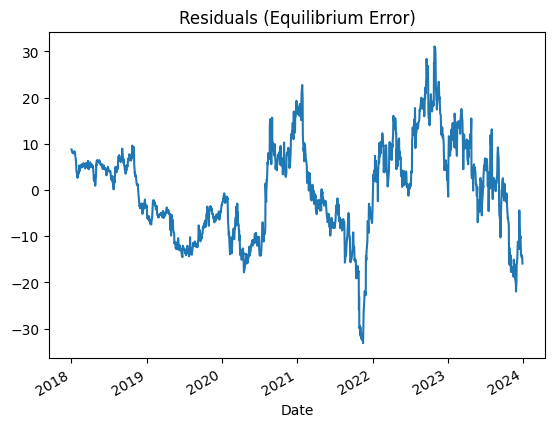

In [19]:
data['residuals'] = model.resid

# Plot residuals
data['residuals'].plot(title="Residuals (Equilibrium Error)")
plt.show()

The graph shows that both AAPL and MSFT price series are non-stationary, as they exhibit clear upward trends and changing variance over time. However, the two series move closely together, suggesting a strong relationship. Despite being non-stationary individually, their co-movement indicates the possibility of a long-run equilibrium relationship (cointegration), where deviations between the two series are stable over time rather than diverging indefinitely.

## Buld Error Correction

In [23]:
# Create differences
data['dAAPL'] = data['AAPL'].diff()
data['dMSFT'] = data['MSFT'].diff()

# Lagged residual
data['lag_resid'] = data['residuals'].shift(1)

# Drop NA values
ecm_data = data.dropna()

# ECM regression
X_ecm = sm.add_constant(ecm_data[['dMSFT', 'lag_resid']])
ecm_model = sm.OLS(ecm_data['dAAPL'], X_ecm).fit()

print(ecm_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  dAAPL   R-squared:                       0.519
Model:                            OLS   Adj. R-squared:                  0.518
Method:                 Least Squares   F-statistic:                     811.3
Date:                Thu, 07 May 2026   Prob (F-statistic):          8.94e-240
Time:                        20:55:22   Log-Likelihood:                -2750.4
No. Observations:                1508   AIC:                             5507.
Df Residuals:                    1505   BIC:                             5523.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0238      0.039      0.615      0.5



## **Error Correction Model (ECM)**

The short-run dynamics are modeled using the Error Correction Model:

$
\Delta AAPL_t = 0.0238 + 0.3940 , \Delta MSFT_t - 0.0147 , u_{t-1} + \varepsilon_t
$

where:

* $ ( \Delta AAPL_t = AAPL_t - AAPL_{t-1} )$,
* ( \ $ Delta MSFT_t = MSFT_t - MSFT_{t-1} ),
  ( u_{t-1} )$ is the lagged equilibrium error,
* ( $ varepsilon_t $) is a white noise error term.

---

### **Interpretation of Parameters**

The coefficient of the lagged residual term $ -0.0147 $ is negative and statistically significant $ p < 0.01 $, which confirms the presence of a long-run equilibrium relationship between the variables.

This coefficient represents the **speed of adjustment** toward equilibrium. Specifically, approximately $ 1.47% $ of any deviation from the long-run equilibrium is corrected in each period. This indicates a relatively slow adjustment process, implying that deviations may persist for several periods before equilibrium is restored.

The coefficient of $ ( \Delta MSFT_t )$  is $ 0.3940 $ and statistically significant $ p < 0.01 $, indicating that short-run changes in Microsoft stock prices have a positive and significant effect on changes in Apple stock prices. A one-unit increase in the change of Microsoft’s stock price leads to an average increase of approximately $ 0.3940 $ units in the change of Apple’s stock price.

The constant term $ 0.0238 $ is not statistically significant $ p > 0.05 $, suggesting that it does not contribute meaningfully to the short-run dynamics of the model.

The $ R^2 $ value of $ 0.519 $ indicates that approximately $ 51.9% $ of the variation in the change of Apple stock prices is explained by the model, which is reasonable for a short-run specification.

---

## **Conclusion**

The results provide strong evidence of a stable long-run equilibrium relationship between Apple and Microsoft stock prices. The Error Correction Model further demonstrates that deviations from this equilibrium are corrected over time, while short-run movements in Microsoft stock prices significantly influence short-run changes in Apple stock prices.

## **Diagnosis**

The adequacy of the Error Correction Model $(ECM)$ is evaluated using the regression output obtained from the $AAPL$ and$ MSFT$ dataset.

* The residuals of the ECM fluctuate around zero, indicating that the model captures the main short-run dynamics between Apple and Microsoft stock prices.

* The Durbin–Watson statistic is approximately ($ 2.009 $), which suggests that there is no significant autocorrelation in the residuals. This implies that the error terms are independent over time and the model is appropriately specified in this regard.

* However, the Jarque–Bera statistic (JB = 2157.878, ($ p = 0.000$ )) indicates that the residuals are not normally distributed. This is likely due to the presence of extreme movements in stock prices, which are common in financial markets.

* The model explains approximately ($ 51.9% $) of the variation in ($ \Delta AAPL_t $) (($ R^2 = 0.519 $)), indicating that while the model captures a substantial portion of short-run movements, other factors not included in the model also influence Apple’s stock price.

#### Overall, the diagnostic results suggest that the ECM is reasonably well specified, although the assumption of normality is violated.

## **Damage**

Despite the effectiveness of the model, several limitations are evident from the results.

* First, the Jarque–Bera test strongly rejects normality $(( p = 0.000 ))$, indicating that the residuals exhibit skewness and kurtosis. This suggests that the model does not fully capture extreme fluctuations in stock prices.

* Second, the speed of adjustment coefficient $(( \gamma = -0.0147 ))$ is relatively small. This implies that only about $( 1.47% )$ of deviations from equilibrium are corrected in each period, meaning that disequilibrium persists for a relatively long time.

* Additionally, the model only includes Microsoft stock as an explanatory variable. Other important factors such as overall market conditions, interest rates, and macroeconomic variables are not included, which may limit the explanatory power of the model.

* Finally, the data may contain structural breaks due to major economic events (e.g., financial crises or global shocks), which are not accounted for in the model and may affect the stability of the estimated relationship.

These limitations suggest that while the model is useful, it does not fully capture all dynamics affecting stock price movements.

## **Directions**

Based on the observed limitations, several improvements can be made to enhance the model.

* Given the non-normality of residuals, the dataset can be refined by removing extreme outliers or by transforming the data, such as using logarithmic returns instead of price levels.

* Additional explanatory variables can be included to improve the model’s explanatory power. For example, incorporating a market index such as the S&P 500 or other macroeconomic indicators may help capture broader market influences.

* Alternative modeling approaches can be considered. A Vector Error Correction Model (VECM) may provide a more comprehensive framework for capturing the joint dynamics between Apple and Microsoft stock prices.

* Testing for structural breaks and adjusting the model accordingly would improve its robustness over different time periods.

* Increasing the sample size or using higher-frequency data may provide more accurate estimates and improve model performance.

## **Deployment**

The estimated ECM for Apple and Microsoft stock prices can be applied in practical financial decision-making.


The existence of a strong long‑term equilibrium between Apple and Microsoft, reflected in the negative adjustment coefficient \((\gamma = -0.0147)\), suggests that price deviations are gradually corrected over time. This insight can be applied in pairs trading, where investors capitalize on temporary mispricing between the two stocks.

For instance, if Apple’s price rises well above the level implied by Microsoft’s, a trader could short Apple and go long Microsoft, anticipating that the two will realign.

The short‑run coefficient \((0.3940)\) shows that Microsoft’s price movements exert a clear and immediate influence on Apple’s short‑term dynamics, making the model useful for forecasting and tactical trading.

That said, the relatively slow adjustment process and evidence of non‑normal residuals highlight the need for caution. The ECM should be complemented with other market indicators and risk management tools.

Overall, the model offers valuable perspective on both the long‑run and short‑run interactions between Apple and Microsoft, supporting more informed and strategic investment decisions.





###  Citations 

1. Hamilton, J. D. (1994). *Time series analysis*. Princeton University Press.  
   [https://press.princeton.edu/books/hardcover/9780691042893/time-series-analysis](https://press.princeton.edu/books/hardcover/9780691042893/time-series-analysis)

2. Tsay, R. S. (2010). *Analysis of financial time series* (3rd ed.). Wiley.  
   [https://www.wiley.com/en-us/Analysis+of+Financial+Time+Series%2C+3rd+Edition-p-9780470414354](https://www.wiley.com/en-us/Analysis+of+Financial+Time+Series%2C+3rd+Edition-p-9780470414354)

3. Enders, W. (2014). *Applied econometric time series* (4th ed.). Wiley.  
   [https://www.wiley.com/en-us/Applied+Econometric+Time+Series%2C+4th+Edition-p-9781118808566](https://www.wiley.com/en-us/Applied+Econometric+Time+Series%2C+4th+Edition-p-9781118808566)

4. Brooks, C. (2019). *Introductory econometrics for finance* (3rd ed.). Cambridge University Press.  
   [https://www.cambridge.org/highereducation/books/introductory-econometrics-for-finance/8C6C4D6C8E5B3E4A0A58E6A3A8F7E5C4](https://www.cambridge.org/highereducation/books/introductory-econometrics-for-finance/8C6C4D6C8E5B3E4A0A58E6A3A8F7E5C4)

5. Greene, W. H. (2018). *Econometric analysis* (8th ed.). Pearson.  
   [https://www.pearson.com/en-us/subject-catalog/p/econometric-analysis/P200000003480](https://www.pearson.com/en-us/subject-catalog/p/econometric-analysis/P200000003480)

6. Engle, R. F., & Granger, C. W. J. (1987). Cointegration and error correction: Representation, estimation, and testing. *Econometrica, 55*(2), 251–276. JSTOR.  
   [https://www.jstor.org/stable/1913236](https://www.jstor.org/stable/1913236)

7. Seabold, S., & Perktold, J. (2010). *Statsmodels: Econometric and statistical modeling with Python*. Statsmodels Documentation.  
   [https://www.statsmodels.org/stable/index.html](https://www.statsmodels.org/stable/index.html)

8. The Pandas Development Team. (2024). *Pandas documentation*.  
   [https://pandas.pydata.org/docs/](https://pandas.pydata.org/docs/)

9. Harris, C. R., et al. (2020). *NumPy documentation*.  
   [https://numpy.org/doc/](https://numpy.org/doc/)

10. Hunter, J. D., et al. (2024). *Matplotlib documentation*.  
   [https://matplotlib.org/stable/index.html](https://matplotlib.org/stable/index.html)

11. Roussi, R. (2024). *yfinance: Yahoo! Finance market data downloader*.  
   [https://ranaroussi.github.io/yfinance/](https://ranaroussi.github.io/yfinance/)

